In [2]:
from pathlib import Path
import pandas as pd, re
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import inspect

main_dir = Path.cwd()
FTABLE = main_dir / "data" / "Tropicana_tito_final_new_quant.csv"

df = pd.read_csv(FTABLE)
plant_metadata = ["row ID", "row m/z", "row retention time", "20240813_58_s84t1_1uL.mzML Peak area", "20240813_60_s86t1_1uL.mzML Peak area"]
df_plants = df[plant_metadata]

# Find columns starting with '20240813'
cols = [col for col in df_plants.columns if col.startswith('20240813')]

# Keep only rows where any of the cells have values >= 100000
df_sub = df_plants[cols].fillna(0)
mask = (df_sub >= 100000).any(axis=1)
df_filtered = df_plants[mask]

MACLEAYA_FTABLE = main_dir / "macleaya_ftable.csv"
df_filtered.to_csv(MACLEAYA_FTABLE, index=False)

In [3]:
# Subset of Macleaya features from bigger plant dataset
macleaya_ftable = pd.read_csv(MACLEAYA_FTABLE)
# Analysis of fractions from Macleaya microcarpa and Macleaya cordata
ftable_84_86 = pd.read_csv(main_dir / "data" / "84_86_ftable.csv")

# Storage for matched rows
matched_rows = []

# Initialize structure to collect multiple match messages
multiple_matches = []

# Iterate through each row in macleaya_ftable
for _, mac_row in macleaya_ftable.iterrows():
    # Calculate absolute difference in 'row m/z' for all rows in ftable_84_86
    mz_matches = ftable_84_86[abs(ftable_84_86['row m/z'] - mac_row['row m/z']) <= 0.005]

    # Further filter matches by 'row retention time' tolerance
    rt_matches = mz_matches[abs(mz_matches['row retention time'] - mac_row['row retention time']) <= 0.2]

    # Check number of matches
    if len(rt_matches) > 1:
        multiple_matches.append(f"Feature ({mac_row['row ID']}) has multiple matches")
    elif len(rt_matches) == 1:
        # Only one match, store needed information
        match = rt_matches.iloc[0]
        matched_rows.append({
            'row ID': mac_row['row ID'],
            'macleaya row m/z': mac_row['row m/z'],
            '84_86 row m/z': match['row m/z'],
            'macleaya row retention time': mac_row['row retention time'],
            '84_86 row retention time': match['row retention time'],
        })

# Print features with multiple matches
if multiple_matches:
    for msg in multiple_matches:
        print(msg)
else:
    # If no multiple matches, create DataFrame and save as CSV
    macleaya_matched = pd.DataFrame(matched_rows)
    macleaya_matched.to_csv(main_dir / "macleaya_matched.csv", index=False)



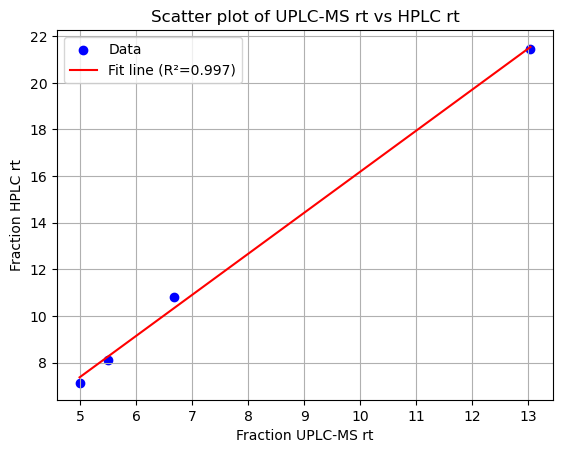

R²: 0.997
Equation: y = 1.758 * x + -1.395


In [4]:
#Selected subset of manually selected matches for regression
manual_guesses = main_dir / "data" / "manual_guesses.xlsx"
df = pd.read_excel(manual_guesses)

# Reshape x (rt of features from fractions analyzed on UPLC-MS) to be a 2D array for sklearn
x = df['84_86 row retention time'].values.reshape(-1, 1)
# The same features but from HPLC analysis
y = df['HPLC rt'].values

model = LinearRegression().fit(x, y)
y_pred = model.predict(x)
r2 = r2_score(y, y_pred)

plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, y_pred, color='red', label=f'Fit line (R²={r2:.3f})')
plt.xlabel('Fraction UPLC-MS rt')
plt.ylabel('Fraction HPLC rt')
plt.title('Scatter plot of UPLC-MS rt vs HPLC rt')
plt.legend()
plt.grid(True)
plt.show()

print(f'R²: {r2:.3f}')

slope_frac_HPLC = model.coef_[0]
intercept_frac_HPLC = model.intercept_
print(f'Equation: y = {slope_frac_HPLC:.3f} * x + {intercept_frac_HPLC:.3f}')



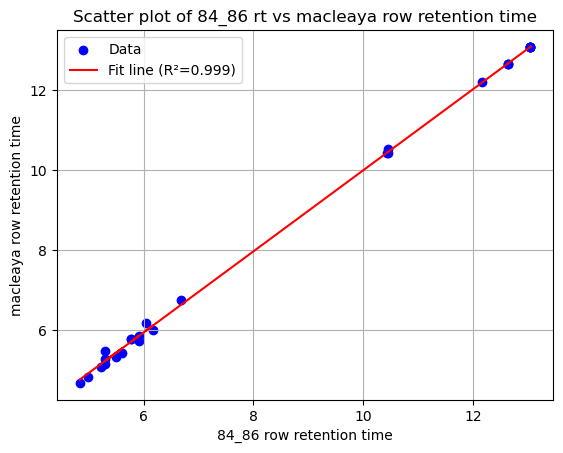

R²: 0.999
Equation: y = 1.014 * x + -0.148


In [5]:
# Subset of Macleaya features from bigger plant dataset
MATCHES = main_dir / "macleaya_matched.csv"
df2 = pd.read_csv(MATCHES)

# Fraction rt (x) vs Plant extract rt (y) (both UPLC-MS)
x = df2['84_86 row retention time'].values.reshape(-1, 1)
y = df2['macleaya row retention time'].values

model = LinearRegression().fit(x, y)
y_pred = model.predict(x)
r2 = r2_score(y, y_pred)

plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, y_pred, color='red', label=f'Fit line (R²={r2:.3f})')
plt.xlabel('84_86 row retention time')
plt.ylabel('macleaya row retention time')
plt.title('Scatter plot of 84_86 rt vs macleaya row retention time')
plt.legend()
plt.grid(True)
plt.show()

print(f'R²: {r2:.3f}')

slope_frac_ex = model.coef_[0]
intercept_frac_ex = model.intercept_
print(f'Equation: y = {slope_frac_ex:.3f} * x + {intercept_frac_ex:.3f}')

In [6]:
# Plant extract feature table
df = pd.read_csv(FTABLE)

# 84 is Macleaya microcarpa, 86 is Macleaya cordata
S84_COL = "20240813_58_s84t1_1uL.mzML Peak area"
S86_COL = "20240813_60_s86t1_1uL.mzML Peak area"

def predict_HPLC_rt_row(row):
    # get peak areas and convert to numeric (invalid -> NaN)
    s84 = pd.to_numeric(row.get(S84_COL), errors='coerce')
    s86 = pd.to_numeric(row.get(S86_COL), errors='coerce')
    # treat missing or non-numeric as zero (no detected signal)
    s84 = 0 if pd.isna(s84) else s84
    s86 = 0 if pd.isna(s86) else s86
    # if either sample shows a signal, compute predicted HPLC RT
    if (s84 > 0) or (s86 > 0):
        X = row['row retention time']
        return slope_frac_HPLC * ((X - intercept_frac_ex) / slope_frac_ex ) + intercept_frac_HPLC
    else:
        return "Not found in Macleaya"

df['predicted_HPLC_rt'] = df.apply(predict_HPLC_rt_row, axis=1)

In [7]:
# quick summary of prediction coverage
total = len(df)
if total == 0:
    print("FTABLE is empty")
else:
    not_found = int((df['predicted_HPLC_rt'] == "Not found in Macleaya").sum())
    pct = not_found / total
    print(f"Total rows in FTABLE: {total:,}")
    print(f"Rows 'Not found in Macleaya': {not_found:,} ({pct:.1%})")

    # New: counts by sample presence
    s84_vals = pd.to_numeric(df[S84_COL], errors='coerce').fillna(0)
    s86_vals = pd.to_numeric(df[S86_COL], errors='coerce').fillna(0)
    only_84 = int(((s84_vals > 0) & (s86_vals == 0)).sum())
    only_86 = int(((s86_vals > 0) & (s84_vals == 0)).sum())
    both_84_86 = int(((s84_vals > 0) & (s86_vals > 0)).sum())
    print(f"Rows with signal only in 84: {only_84:,}")
    print(f"Rows with signal only in 86: {only_86:,}")
    print(f"Rows with signal in both 84 and 86: {both_84_86:,}")

Total rows in FTABLE: 40,013
Rows 'Not found in Macleaya': 27,743 (69.3%)
Rows with signal only in 84: 2,104
Rows with signal only in 86: 2,318
Rows with signal in both 84 and 86: 7,848


In [8]:
# Save the enhanced DataFrame with prediction column
df.to_csv(main_dir / "tropicana_HPLC_predictions.csv", index=False)

In [9]:
# Metadata about fraction start, end and corresponding fraction number
UV_FRACTIONS = main_dir / "data" / "UV_times_comma.csv"

# Previously created file with predictions
RT_PREDICTIONS = main_dir / "tropicana_HPLC_predictions.csv"

df_frac = pd.read_csv(UV_FRACTIONS)
df_predict = pd.read_csv(RT_PREDICTIONS)

print("UV_times.csv columns (raw repr):", [repr(c) for c in df_frac.columns.tolist()])

UV_times.csv columns (raw repr): ["'Fraction#'", "'AFC Loc'", "'Start'", "'End'", "'Volume'"]


In [10]:
def match_fractions(df_predict: pd.DataFrame, df_frac: pd.DataFrame,
                    time_col: str = "predicted_HPLC_rt",
                    start_col: str = "Start", end_col: str = "End", frac_col: str = "Fraction#") -> pd.DataFrame:
    """
    Returns a copy of df_predict with a new column 'matched_fraction'.
    Rules:
      - If time is between Start and End (inclusive) -> that fraction (or multiple, if overlapping)
      - If time is strictly between End_i and Start_{i+1} -> "frac_i & frac_{i+1}"
      - If time < first Start or > last End -> "Fraction not collected"
    """
    # Defensive copy + strip whitespace in column names
    df_f = df_frac.copy().rename(columns=lambda s: s.strip())
    df_p = df_predict.copy().rename(columns=lambda s: s.strip())

    # Ensure start/end numeric and sort by start
    df_f[start_col] = pd.to_numeric(df_f[start_col], errors='coerce')
    df_f[end_col]   = pd.to_numeric(df_f[end_col],   errors='coerce')
    df_f = df_f.sort_values(by=start_col).reset_index(drop=True)

    starts = df_f[start_col].to_numpy()
    ends   = df_f[end_col].to_numpy()

    results = []
    # iterate rows of predictions
    for t in df_p[time_col].astype(str):
        # Handle "Not found in Macleaya" case
        if t == "Not found in Macleaya":
            results.append("Not found in Macleaya")
            continue
            
        # Convert to float for valid entries
        t = float(t)
        
        # between start[i] and end[i]
        mask = (df_f[start_col] <= t) & (df_f[end_col] >= t)
        if mask.any():
            fracs = df_f.loc[mask, frac_col].astype(str).tolist()
            results.append(" & ".join(fracs))
            continue

        # outside the whole collected range (t < first Start or t > last End)
        if np.isnan(starts).any() or np.isnan(ends).any():
            results.append("Fraction not collected")
            continue
        if t < starts[0] or t > ends[-1]:
            results.append("Fraction not collected")
            continue

        # strictly between two adjacent fractions (ends[i] < t < starts[i+1])
        assigned = False
        for i in range(len(df_f)-1):
            if (ends[i] < t) and (t < starts[i+1]):
                results.append(f"{df_f.loc[i, frac_col]} & {df_f.loc[i+1, frac_col]}")
                assigned = True
                break
        if not assigned:
            # fallback safety
            results.append("Fraction not collected")

    df_p = df_p.copy()
    df_p["matched_fraction"] = results
    return df_p

try:
    df_frac = pd.read_csv(UV_FRACTIONS)
    df_predict = pd.read_csv (RT_PREDICTIONS)
    df_matched = match_fractions(df_predict, df_frac,
                                 time_col="predicted_HPLC_rt",
                                 start_col="Start", end_col="End", frac_col="Fraction#")

    # attach back to df_predict variable name used earlier
    df_predict = df_matched

    # Save a copy
    out_path = main_dir / "tropicana_fraction_predictions.csv"
    df_predict.to_csv(out_path, index=False)
    print(f"Done — saved matched table to: {out_path}")

except NameError:
    print("UV_FRACTIONS or RT_PREDICTIONS variable not found in this session. "
          "If you're running this as a standalone cell, set:\n"
          "UV_FRACTIONS = Path('data/UV_times.csv')\n"
          "RT_PREDICTIONS = Path('data/tropicana_HPLC_predictions.csv')\n"
          "or pass file paths to pd.read_csv and call match_fractions(df_predict, df_frac).")

except FileNotFoundError as e:
    print(f"File missing: {e}. Make sure UV_times.csv and predictions CSV are in the expected paths.")

Done — saved matched table to: c:\Users\bouch\OneDrive\Plocha\IOCB_Erik\PROJECTS\microfractionation\scripts\fraction_predictor\tropicana_fraction_predictions.csv


In [ ]:
# Fraction fluorescence per fraction
FLUORE_84 = "data/fractions_84_UV_clean.xlsx"
FLUORE_86 = "data/fractions_86_UV_clean.xlsx"

df1 = pd.read_excel(FLUORE_84)
df2 = pd.read_excel(FLUORE_86)

fluore_files = [
    (df1, "FLUORE_84"),
    (df2, "FLUORE_86")
]

# Calculating normalized fluorescence and percentage
for df, name in fluore_files:
    df['avg'] = df['average']
    pos = df['pos_avg'].iloc[0]
    df['fluore_control'] = df['avg'] / pos
    df['fluore_pct'] = df['fluore_control'] / df['fluore_control'].max() * 100
    df.to_csv(f"pct_{name}.csv")



Saved bioactivity data to: c:\Users\bouch\OneDrive\Plocha\IOCB_Erik\PROJECTS\microfractionation\scripts\fraction_predictor\bioactivity_84.csv
Saved bioactivity data to: c:\Users\bouch\OneDrive\Plocha\IOCB_Erik\PROJECTS\microfractionation\scripts\fraction_predictor\bioactivity_86.csv


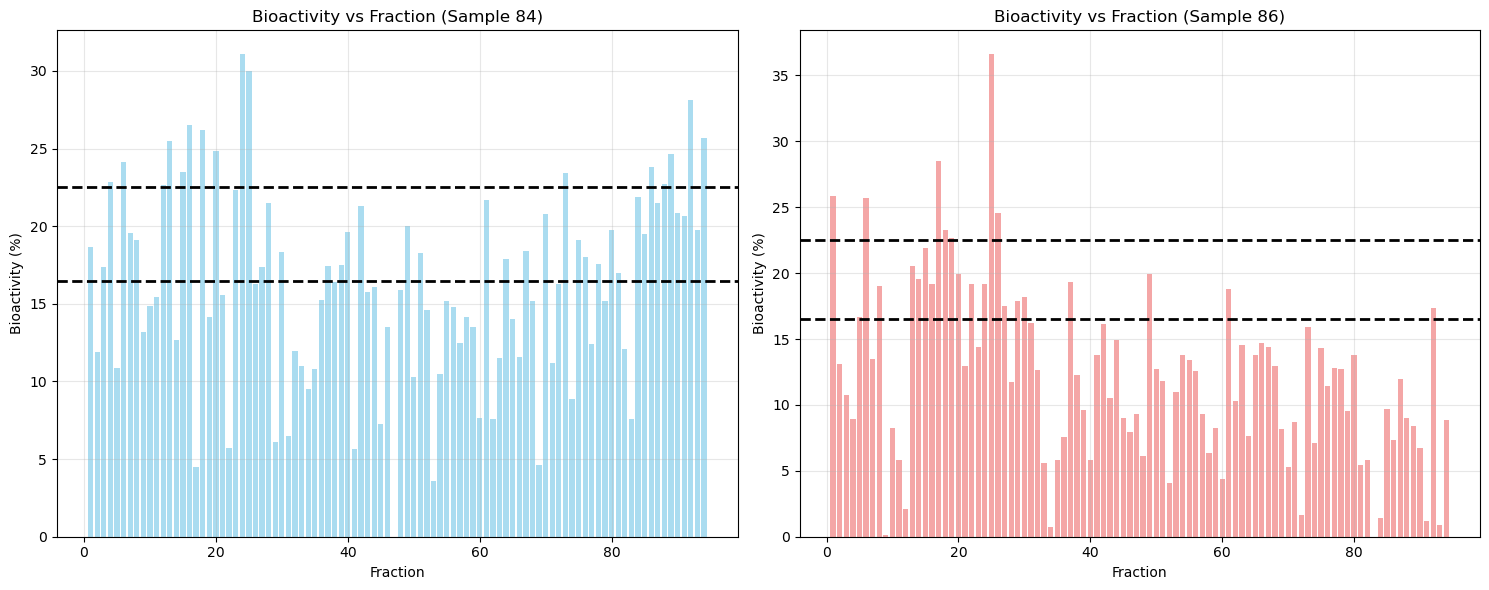


Sample 84 - Bioactivity Stats:
  Mean: 16.28%
  Max: 31.06%
  Min: 0.00%

Sample 86 - Bioactivity Stats:
  Mean: 12.25%
  Max: 36.59%
  Min: 0.00%


In [ ]:

# Calculate bioactivity (100 - fluore_pct) and create bar charts
def calculate_bioactivity_and_plot():
    
    fluore_84_file = main_dir / "pct_FLUORE_84.csv"
    fluore_86_file = main_dir / "pct_FLUORE_86.csv"
    
    # Check if files exist
    if not fluore_84_file.exists():
        print(f"File not found: {fluore_84_file}")
        return
    if not fluore_86_file.exists():
        print(f"File not found: {fluore_86_file}")
        return
    
    # Read the files
    df_84 = pd.read_csv(fluore_84_file)
    df_86 = pd.read_csv(fluore_86_file)
    
    # Calculate bioactivity (100 - fluore_pct)
    df_84['bioactivity'] = 100 - df_84['fluore_pct']
    df_86['bioactivity'] = 100 - df_86['fluore_pct']

    
    # Save to new CSV files
    bioactivity_84_file = main_dir / "bioactivity_84.csv"
    bioactivity_86_file = main_dir / "bioactivity_86.csv"
    
    df_84.to_csv(bioactivity_84_file, index=False)
    df_86.to_csv(bioactivity_86_file, index=False)
    
    print(f"Saved bioactivity data to: {bioactivity_84_file}")
    print(f"Saved bioactivity data to: {bioactivity_86_file}")
    
    # Create bar charts
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot for sample 84
    ax1.bar(df_84['fraction'], df_84['bioactivity'], color='skyblue', alpha=0.7)
    ax1.set_xlabel('Fraction')
    ax1.set_ylabel('Bioactivity (%)')
    ax1.set_title('Bioactivity vs Fraction (Sample 84)')
    ax1.grid(True, alpha=0.3)
    # Add dashed lines
    ax1.axhline(y=22.5, color='k', linestyle='--', linewidth=2)
    ax1.axhline(y=16.5, color='k', linestyle='--', linewidth=2)

    # Plot for sample 86
    ax2.bar(df_86['fraction'], df_86['bioactivity'], color='lightcoral', alpha=0.7)
    ax2.set_xlabel('Fraction')
    ax2.set_ylabel('Bioactivity (%)')
    ax2.set_title('Bioactivity vs Fraction (Sample 86)')
    ax2.grid(True, alpha=0.3)
    # Add dashed lines
    ax2.axhline(y=22.5, color='k', linestyle='--', linewidth=2)
    ax2.axhline(y=16.5, color='k', linestyle='--', linewidth=2)

    
    plt.tight_layout()
    plt.show()
    
    # Print basic statistics
    print(f"\nSample 84 - Bioactivity Stats:")
    print(f"  Mean: {df_84['bioactivity'].mean():.2f}%")
    print(f"  Max: {df_84['bioactivity'].max():.2f}%")
    print(f"  Min: {df_84['bioactivity'].min():.2f}%")
    
    print(f"\nSample 86 - Bioactivity Stats:")
    print(f"  Mean: {df_86['bioactivity'].mean():.2f}%")
    print(f"  Max: {df_86['bioactivity'].max():.2f}%")
    print(f"  Min: {df_86['bioactivity'].min():.2f}%")
    
    return df_84, df_86

# Execute the function
df_bioactivity_84, df_bioactivity_86 = calculate_bioactivity_and_plot()


In [18]:
# Create bioactivity groups - new standalone block
df_84_copy = df_bioactivity_84.copy()
df_86_copy = df_bioactivity_86.copy()

# Group based on bioactivity values
def assign_group(bioactivity_value):
    if bioactivity_value >= 22.5:
        return 'group_above_22.5'
    elif bioactivity_value >= 16.5:
        return 'group_16.5_to_22.5'
    else:
        return 'group_below_16.5'

# Apply grouping
df_84_copy['group'] = df_84_copy['bioactivity'].apply(assign_group)
df_86_copy['group'] = df_86_copy['bioactivity'].apply(assign_group)

# Save to CSV files
df_84_copy.to_csv(main_dir / "bioactivity_groups_84.csv", index=False)
df_86_copy.to_csv(main_dir / "bioactivity_groups_86.csv", index=False)

print("Saved bioactivity_groups_84.csv and bioactivity_groups_86.csv")

# Show group counts
print(f"\nSample 84 groups:")
print(df_84_copy['group'].value_counts())
print(f"\nSample 86 groups:")
print(df_86_copy['group'].value_counts())

Saved bioactivity_groups_84.csv and bioactivity_groups_86.csv

Sample 84 groups:
group
group_below_16.5      49
group_16.5_to_22.5    29
group_above_22.5      16
Name: count, dtype: int64

Sample 86 groups:
group
group_below_16.5      71
group_16.5_to_22.5    16
group_above_22.5       7
Name: count, dtype: int64


In [ ]:
main_dir = Path.cwd()
INPUT_FTABLE = main_dir / "tropicana_fraction_predictions.csv"
BIO_84 = main_dir / "bioactivity_groups_84.csv"
BIO_86 = main_dir / "bioactivity_groups_86.csv"
FINAL_FTABLE = main_dir / "tropicana_bioactivity_groups.csv"

# quick existence check
for p in (INPUT_FTABLE, BIO_84, BIO_86):
    if not p.exists():
        raise FileNotFoundError(f"Required file not found: {p}")

df_pred = pd.read_csv(INPUT_FTABLE)
df_84 = pd.read_csv(BIO_84)
df_86 = pd.read_csv(BIO_86)

# Detect fraction and group columns
def find_fraction_and_group_columns(df):
    cols = list(df.columns)
    frac_col = next((c for c in cols if c.lower() in ('fraction','fractions','fraction#','fraction_number')), None)
    group_col = next((c for c in cols if c.lower() == 'group'), None)
    if frac_col is None:
        frac_col = next((c for c in cols if 'fraction' in c.lower()), None)
    if group_col is None:
        group_col = next((c for c in cols if 'group' in c.lower()), None)
    if not frac_col or not group_col:
        raise ValueError(f"Couldn't detect fraction/group columns. cols: {cols}")
    return frac_col, group_col

frac84_col, group84_col = find_fraction_and_group_columns(df_84)
frac86_col, group86_col = find_fraction_and_group_columns(df_86)

# normalize fraction column to simple string for exact matching
df_84['_frac_norm'] = df_84[frac84_col].astype(str).str.strip()
df_86['_frac_norm'] = df_86[frac86_col].astype(str).str.strip()
df_84['_map_group'] = df_84[group84_col]
df_86['_map_group'] = df_86[group86_col]

def parse_matched_fraction(s):
    if pd.isna(s): return None
    s = str(s).strip()
    if 'not collected' in s.lower() or 'not found in macleaya' in s.lower(): return None
    nums = re.findall(r'\d+', s)
    if not nums: return None
    return sorted({int(x) for x in nums})

# Bioactivity (1-fluorescence) groups based on previous graphs
PRIORITY = ['group_above_22.5','group_16.5_to_22.5','group_below_16.5']

def pick_group(fracs, df_map):
    if fracs is None:
        return "No data"
    groups = []
    for f in fracs:
        matches = df_map[df_map['_frac_norm'] == str(f)]['_map_group'].tolist()
        if matches:
            groups.extend(matches)
    if not groups:
        return "No data"
    for p in PRIORITY:
        if p in groups:
            return p
    return groups[0]

df_pred['parsed_fracs'] = df_pred['matched_fraction'].apply(parse_matched_fraction)
df_pred['bioactivity_in_84'] = df_pred['parsed_fracs'].apply(lambda x: pick_group(x, df_84))
df_pred['bioactivity_in_86'] = df_pred['parsed_fracs'].apply(lambda x: pick_group(x, df_86))

# ensure "Fraction not collected" and "Not found in Macleaya" -> "No data"
mask_none = df_pred['parsed_fracs'].isna()
df_pred.loc[mask_none, ['bioactivity_in_84','bioactivity_in_86']] = "No data"

# Explicitly mark "Not found in Macleaya" rows
mask_not_found = df_pred['matched_fraction'] == "Not found in Macleaya"
df_pred.loc[mask_not_found, ['bioactivity_in_84','bioactivity_in_86']] = "Not found in Macleaya"

df_pred.to_csv(FINAL_FTABLE, index=False)
print("Saved:", FINAL_FTABLE)

Saved: c:\Users\bouch\OneDrive\Plocha\IOCB_Erik\PROJECTS\microfractionation\scripts\fraction_predictor\tropicana_bioactivity_groups.csv


In [ ]:
# Previously created file with predictions for
BIOAC_FTABLE  = main_dir / "tropicana_bioactivity_groups.csv"

# Similar feature table as initial just with feature area columns renamed to plant sp. name and SIRIUS annotations
SIRIUS_FTABLE = main_dir / "data" / "feature_table_everything.csv"

# Read files
ft = pd.read_csv(SIRIUS_FTABLE)
bio = pd.read_csv(BIOAC_FTABLE)

# Ensure 'row ID' exists
for df, name in ((ft, "feature_table_everything"), (bio, "tropicana_bioactivity_groups")):
    if 'row ID' not in df.columns:
        raise KeyError(f"'row ID' column not found in {name} (path: {SIRIUS_FTABLE if name.startswith('feature') else BIOAC_FTABLE})")

# Normalize row ID to integer-ish values for robust matching (nullable Int)
ft['row_id_norm']  = pd.to_numeric(ft['row ID'], errors='coerce').astype('Int64')
bio['row_id_norm'] = pd.to_numeric(bio['row ID'], errors='coerce').astype('Int64')

# Columns to take from bio file
wanted = ["predicted_HPLC_rt", "matched_fraction", "parsed_fracs", "bioactivity_in_84", "bioactivity_in_86"]
present_wanted = [c for c in wanted if c in bio.columns]
missing_wanted = [c for c in wanted if c not in bio.columns]
if missing_wanted:
    print("Warning: these expected columns are missing in bio file and will not be appended:", missing_wanted)

# Prepare bio subset for merge
bio_sub = bio[['row_id_norm'] + present_wanted].drop_duplicates(subset=['row_id_norm'])

# Merge (left join to keep original order/rows)
merged = ft.merge(bio_sub, on='row_id_norm', how='left')

# Number of matched rows (where bio had data for that row ID)
matched_count = merged['row_id_norm'].notna() & merged[present_wanted[0]].notna() if present_wanted else merged['row_id_norm'].notna()
# If we have at least one wanted column, count non-null in that column; otherwise count based on row_id_norm presence
if present_wanted:
    matched_count = int(merged[present_wanted[0]].notna().sum())
else:
    matched_count = int(ft['row_id_norm'].isin(bio_sub['row_id_norm']).sum())

print(f"Rows in feature_table_everything: {len(ft):,}")
print(f"Rows matched by 'row ID' (i.e. rows that will receive bio columns): {matched_count:,}")

# Print what will be appended for specific ID X (if present)
check_id = 24880
row = bio_sub[bio_sub['row_id_norm'] == check_id]
if not row.empty:
    to_print = row.iloc[0].to_dict()
    # remove the internal normalized key from display
    to_print.pop('row_id_norm', None)
    print(f"\nValues to append for ID {check_id}:")
    print(to_print)
else:
    print(f"\nID {check_id} not found in {BIOAC_FTABLE} (or has no numeric 'row ID').")

# Drop helper column(s) and save result to a new file (safer than overwriting)
OUT = SIRIUS_FTABLE.with_name(SIRIUS_FTABLE.stem + "_with_bio" + SIRIUS_FTABLE.suffix)
# remove helper column before saving
out_df = merged.drop(columns=['row_id_norm'])
out_df.to_csv(OUT, index=False)
print(f"\nSaved updated feature table with appended bio columns to: {OUT}")


Rows in feature_table_everything: 40,013
Rows matched by 'row ID' (i.e. rows that will receive bio columns): 40,013

Values to append for ID 24880:
{'predicted_HPLC_rt': '11.329039842473492', 'matched_fraction': '25', 'parsed_fracs': '[25]', 'bioactivity_in_84': 'group_above_22.5', 'bioactivity_in_86': 'group_above_22.5'}

Saved updated feature table with appended bio columns to: c:\Users\bouch\OneDrive\Plocha\IOCB_Erik\PROJECTS\microfractionation\scripts\fraction_predictor\data\feature_table_everything_with_bio.csv
